In [1]:
import numpy as np
import matplotlib.pyplot as plt
import beamsplitter_utils as bs

Say I have a dielectric beamsplitter which I would like to understand between 0 and 300 GHz. Given the thickness and material of the beamsplitter, as well as the incident angle of the beam relative to the beamsplitter surface normal, I can return the behavior of the beamsplitter as follows:

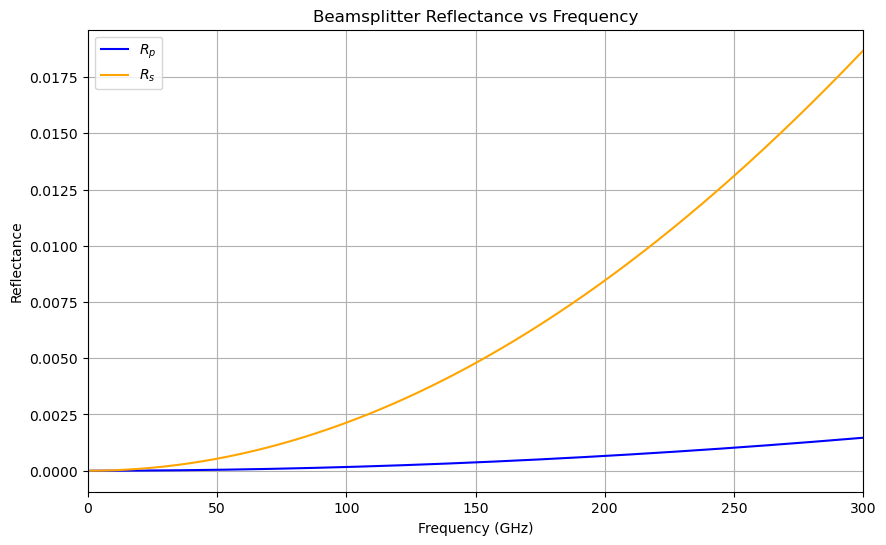

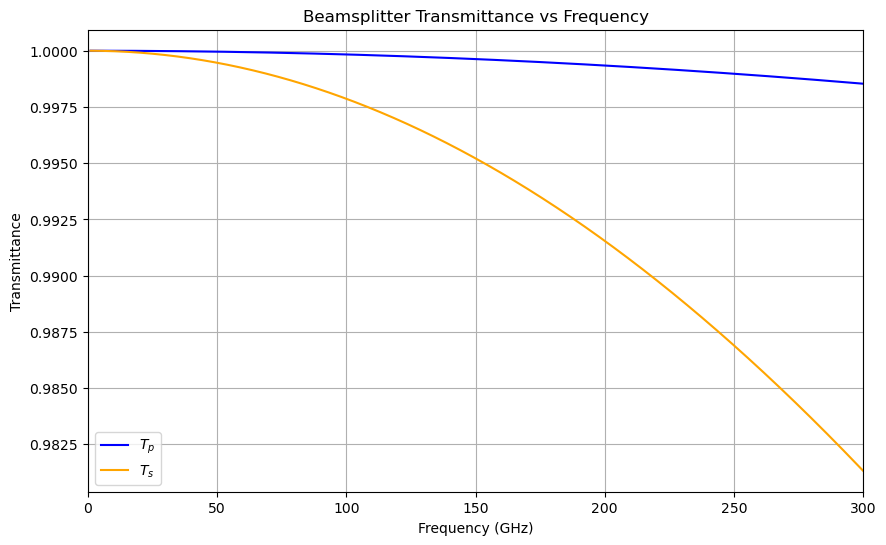

In [2]:
# generate array of frequencies in Hz
nus = np.linspace(1e9, 300e9, 5000)

h = 25e-6 # set the thickness of the beamsplitter in m; this is 25 microns
theta = 45 # set the angle of incidence in degrees
material = 'PP' # set the material to polypropylene

R_p, R_s, R_avg = bs.beamsplitter_reflectance(nus, h, theta, material=material)
T_p, T_s, T_avg = bs.beamsplitter_transmittance(nus, h, theta, material=material)

# generate reflectance plot
plt.figure(figsize=(10, 6))
plt.plot(nus*1e-9, R_p, label=r'$R_p$', color='blue')
plt.plot(nus*1e-9, R_s, label=r'$R_s$', color='orange')
plt.title('Beamsplitter Reflectance vs Frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Reflectance')
plt.grid()
plt.legend()
plt.xlim(0, 300)
plt.show()

# generate transmittance plot
plt.figure(figsize=(10, 6))
plt.plot(nus*1e-9, T_p, label=r'$T_p$', color='blue')
plt.plot(nus*1e-9, T_s, label=r'$T_s$', color='orange')
plt.title('Beamsplitter Transmittance vs Frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmittance')
plt.grid()
plt.legend()
plt.xlim(0, 300)
plt.show()

The definitions of $R_s$ and $R_p$ are the standard ones: $R_s$ corresponds to light polarized perpendicular to the plane of incidence, and $R_p$ corresponds to light polarized parallel to the plane of incidence.  

Absorption is included in the beamsplitter_utils module, which is based entirely on analytic models. One can easily look at absorption for a polarization $i$ by plotting $1 - R_{i} - T_{i}$.

Finally, this module currently supports the following materials:

In [4]:
bs.available_materials()

LDPE
Acrylic 31
Spectrosil
Pyrex
HDPE
Macor
Nylon
Paraffin
PE
PETP
PMMA
PS
PTFE(Teflon)
Fused Quartz (Herasil)
Rexolite
Silicon
TPX (Sheet)
PP


If you would like to plot the response of a beamsplitter made of a different material, you can do so by specifying $n$, the real part of its complex refractive index, and $\epsilon$, the real part of its complex permittivity, when calling beamsplitter_reflectance and beamsplitter_transmittance.